# Neural Networks

## Multi Layer Perceptron

As a first step, we will implement a MultiLayer Perceptron (MLP) to test it on the classic iris dataset. 

1. Load the iris dataset and split it into train and test sets 
> Check the previous pratical sessions !

2. Built a Multi Layer Perceptron with default parameters and evaluate its accuracy on test set.

3. Plot the loss curve by using the `loss_curve_` attribute of `MLPClassifier`

4. Change the `max_iter` to 100 and check the curve and the output.


In [27]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.3)

/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (110) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (160) reached and the optimization hasn't converged yet.
  w

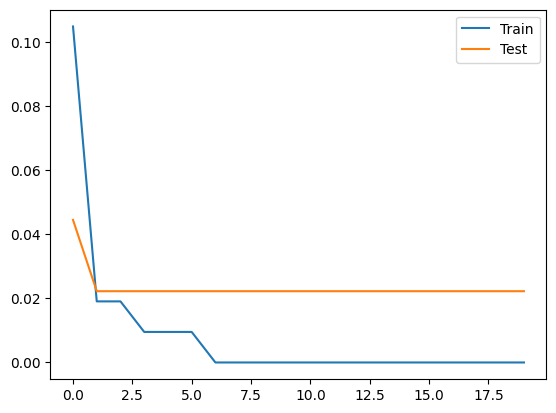

In [29]:
from sklearn.neural_network import MLPClassifier
import numpy as np
acc_train = []
acc_test = []
for i in range(10,1000,50):
    mlp = MLPClassifier(max_iter=i,early_stopping=False, tol=0, hidden_layer_sizes=[100,100,30])
    mlp.fit(X_train, y_train)
    ypred = mlp.predict(X_test)
    acc_train.append(1- np.mean(y_train== mlp.predict(X_train)))
    acc_test.append(1- np.mean(y_test== mlp.predict(X_test)))



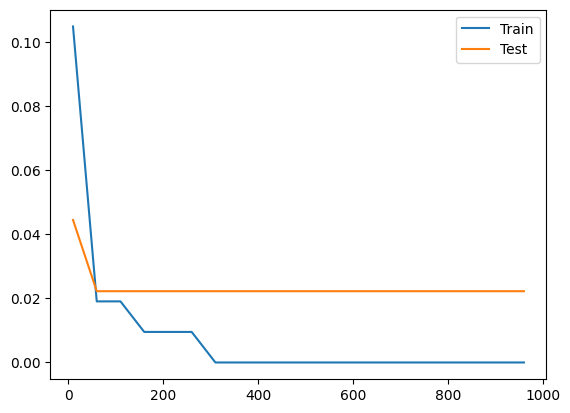

In [30]:
plt.plot(range(10,1000,50),acc_train,label="Train")
plt.plot(range(10,1000,50),acc_test,label="Test")
plt.legend()


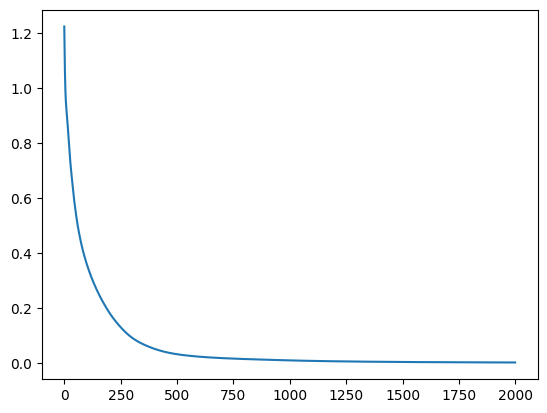

In [24]:
import matplotlib.pyplot as plt 
plt.plot(mlp.loss_curve_)

## Are Neural Networks better than classic ML ?

To answer this question, we will investigate if using a MLP can beat a tree based approach on the COBRA dataset seen in the previous practical session. As the results indicate that the descriptors XX work better, we will stick on this data. 

The purpose of this section is to design a fair experiment between the two methods: 
1. What are the key points to take care to have a fair comparison ?  
2. What hyperparameters will you tune ? how many values ?  
3. Write down explicly your experimental protocol

Once these points are clear for you, start your implementation of different methods. 

In [32]:
from sklearn.model_selection import train_test_split

# RF vs MLP
from datasets.cobra import CobraDataset

data_Cobra = CobraDataset()
X_cobra_graph = data_Cobra.graph_data
X_cobra_atom = data_Cobra.atom_data
X_cobra_graph_atom = data_Cobra.all_data
y_cobra = data_Cobra.targets

import pickle
with open("cobra_data.pkl","wb") as f:
    pickle.dump({"X_cobra_graph" : X_cobra_graph,
                  "X_cobra_atom" : X_cobra_atom, 
                  "X_cobra_graph_atom" : X_cobra_graph_atom, 
                  "y_cobra" : y_cobra},f)
import pickle
with open("cobra_data.pkl","rb") as f:
    data_cobra = pickle.load(f)
X_cobra_graph = data_cobra["X_cobra_graph"]
X_cobra_atom = data_cobra["X_cobra_atom"]
X_cobra_graph_atom = data_cobra["X_cobra_graph_atom"]
y_cobra = data_cobra["y_cobra"]

In [33]:
X_cobra_graph.shape

(111, 20)

In [55]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import GridSearchCV

params_knn= {
    "n_neighbors" : [10,5,3], 
}



params_mlp = {
    "max_iter" : [10, 100, 200], 
    "hidden_layer_sizes" : ((10,10), (50), (50,20)),
}

params_rf = {
    "n_estimators" : (10,20,50, 100),
    "max_depth" : (5,10,20)
}

mae_rf = []
mae_mlp = []
mae_knn = []

for _ in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X_cobra_graph,y_cobra,test_size=15)

    mlp = MLPRegressor()
    cv_mlp = GridSearchCV(mlp, params_mlp)
    cv_mlp.fit(X_train, y_train)

    rf = RandomForestRegressor()
    cv_rf = GridSearchCV(rf, params_rf)
    cv_rf.fit(X_train, y_train)


    knn = KNeighborsRegressor()
    cv_knn = GridSearchCV(knn, params_knn)
    cv_knn.fit(X_train, y_train)

    ypred = cv_mlp.predict(X_test)
    mae_mlp.append(np.mean(np.abs(y_test - ypred )))

    ypred = cv_rf.predict(X_test)
    mae_rf.append(np.mean(np.abs(y_test - ypred )))
    
    
    ypred = cv_knn.predict(X_test)
    mae_knn.append(np.mean(np.abs(y_test - ypred )))
    


/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  war

/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
 

/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  w

/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
 

/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  wa

...

/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  wa

/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  

/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
 

/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  wa

/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/work/Cours/IML/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
 

In [56]:

ypred = cv_mlp.predict(X_test)
print(f"Erreur moyenne MLP : {np.mean(mae_mlp):.4f}  +- {np.std(mae_mlp):.4f}")

ypred = cv_rf.predict(X_test)
print(f"Erreur moyenne RF : {np.mean(mae_rf):.4f} +- {np.std(mae_rf):.4f} ")

ypred = cv_knn.predict(X_test)
print(f"Erreur moyenne KNN : {np.mean(mae_knn):.4f} +- {np.std(mae_knn):.4f} ")





Erreur moyenne MLP : 1.4795  +- 0.2598
Erreur moyenne RF : 1.4910 +- 0.2099 
Erreur moyenne KNN : 1.7869 +- 0.3960 


<BarContainer object of 3 artists>

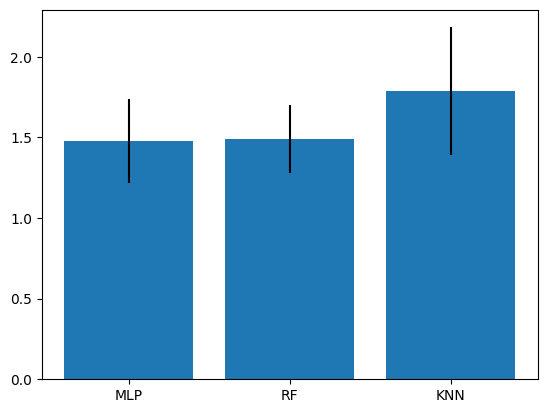

In [57]:
plt.bar(("MLP", "RF", "KNN"), (np.mean(mae_mlp),np.mean(mae_rf), np.mean(mae_knn)), yerr=(np.std(mae_mlp),np.std(mae_rf),np.std(mae_knn)))

# Neural Networks for Images

For this section, we will train bigger models on much more data. Let's run it on Colab to benefit from the computer ressources of Google.

Open the online notebook [here](https://colab.research.google.com/drive/1QEWLMCgIwyPaRslo-uyBBznE1BBSQzDV?usp=sharing).